# Multi-Platform Advertising Performance: Statistical Analysis & Strategic Recommendations

Looking at 1,800 campaigns across Google, Meta, and TikTok. Need to figure out which actually performs better.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load and peek at the data
df = pd.read_csv('../AB Testing/global_ads_performance_dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Shape: (1800, 14)

Columns: ['date', 'platform', 'campaign_type', 'industry', 'country', 'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue', 'ROAS']

First few rows:


,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [3]:
# Check what we have
print("Is the data clean?")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

Is the data clean?
date             0
platform         0
campaign_type    0
industry         0
country          0
impressions      0
clicks           0
CTR              0
CPC              0
ad_spend         0
conversions      0
CPA              0
revenue          0
ROAS             0
dtype: int64

Data types:
date              object
platform          object
campaign_type     object
industry          object
country           object
impressions        int64
clicks             int64
CTR              float64
CPC              float64
ad_spend         float64
conversions        int64
CPA              float64
revenue          float64
ROAS             float64
dtype: object


In [11]:
# How many campaigns per platform?
print("Platform breakdown:")
print(df['platform'].value_counts())
print(f"\nCampaign types: {df['campaign_type'].unique()}")
print(f"Industries: {df['industry'].unique()}")

Platform breakdown:
platform
Google Ads    720
Meta Ads      630
TikTok Ads    450
Name: count, dtype: int64

Campaign types: ['Search' 'Video' 'Shopping' 'Display']
Industries: ['Fintech' 'EdTech' 'Healthcare' 'SaaS' 'E-commerce']


## First Look: Raw Metrics by Platform

In [12]:
# What does performance actually look like?
platform_performance = df.groupby('platform').agg({
    'ROAS': ['mean', 'median', 'std', 'min', 'max'],
    'CPA': ['mean', 'median'],
    'CTR': 'mean',
    'conversions': 'sum'
}).round(3)

print(platform_performance)

             ROAS                                CPA            CTR  \
             mean median    std   min    max    mean  median   mean   
platform                                                              
Google Ads  4.113  3.045  3.689  0.13  25.03  64.065  48.245  0.040   
Meta Ads    6.916  4.895  6.446  0.20  38.73  39.097  30.480  0.025   
TikTok Ads  9.539  6.825  8.685  0.39  49.00  29.197  22.215  0.055   

           conversions  
                   sum  
platform                
Google Ads      131098  
Meta Ads         73262  
TikTok Ads      122452  


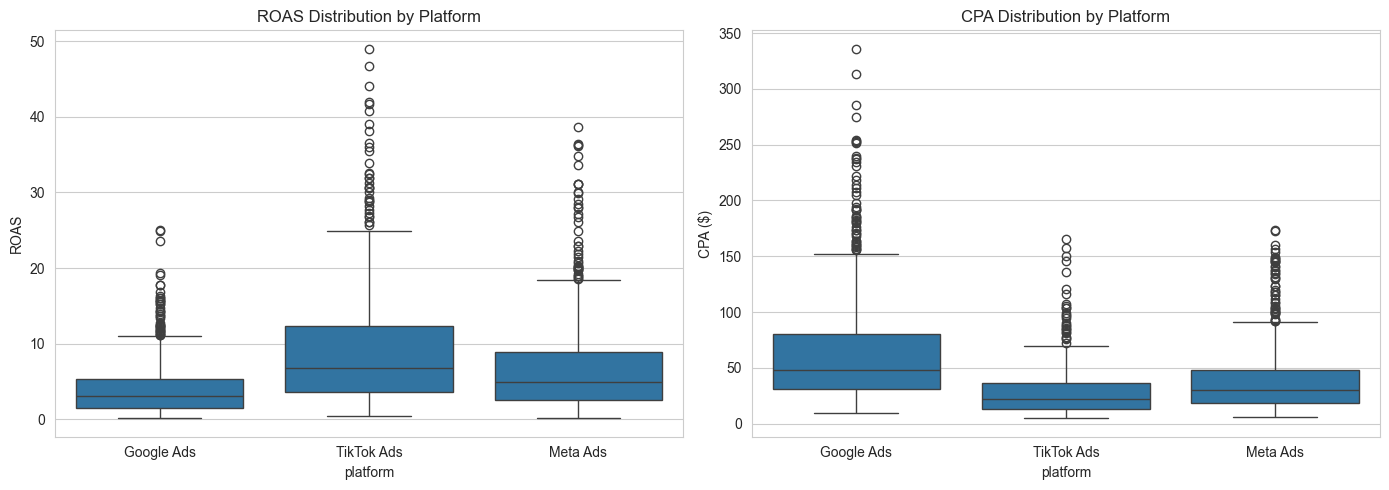

TikTok looks higher in ROAS, but the variance is also way bigger. Hmm.


In [13]:
# Okay interesting—TikTok is way higher. But is this real or selection bias?
# Let me just quickly plot this

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of ROAS
sns.boxplot(data=df, x='platform', y='ROAS', ax=axes[0])
axes[0].set_title('ROAS Distribution by Platform')
axes[0].set_ylabel('ROAS')

# Box plot of CPA (lower is better)
sns.boxplot(data=df, x='platform', y='CPA', ax=axes[1])
axes[1].set_title('CPA Distribution by Platform')
axes[1].set_ylabel('CPA ($)')

plt.tight_layout()
plt.show()

print("TikTok looks higher in ROAS, but the variance is also way bigger. Hmm.")

## Testing: Is This Difference Real?

In [ ]:


google = df[df['platform'] == 'Google Ads']['ROAS'].values
meta = df[df['platform'] == 'Meta Ads']['ROAS'].values
tiktok = df[df['platform'] == 'TikTok Ads']['ROAS'].values

f_stat, p_val = f_oneway(google, meta, tiktok)

print(f"ANOVA Results:")
print(f"F = {f_stat:.2f}")
print(f"P-value = {p_val:.2e}")
print()
if p_val < 0.001:
    print("✓ Definitely significant. Not random noise.")
else:
    print("Not significant—could be random.")

ANOVA Results:
F = 107.65
P-value = 6.96e-45

✓ Definitely significant. Not random noise.


In [14]:
# What are the actual means?
means = df.groupby('platform')['ROAS'].mean().sort_values(ascending=False)
print("Mean ROAS by platform:")
for plat, val in means.items():
    print(f"  {plat:15s}: {val:.3f}x")

# So TikTok is 2.3x higher than Google. That seems huge.
# Question: Why? Better audience? Or are we selecting different campaign types for TikTok?

Mean ROAS by platform:
  TikTok Ads     : 9.539x
  Meta Ads       : 6.916x
  Google Ads     : 4.113x


In [15]:
# Let me check: are different campaign TYPES going to different platforms?
# This would be selection bias.

cross_tab = pd.crosstab(df['campaign_type'], df['platform'], margins=True)
print("Campaign type distribution across platforms:")
print(cross_tab)
print()

# Hmm, it looks like campaign types are spread across platforms
# But let me check if TikTok is getting more of the high-ROAS types

Campaign type distribution across platforms:
platform       Google Ads  Meta Ads  TikTok Ads   All
campaign_type                                        
Display               174       145         101   420
Search                192       160         125   477
Shopping              168       160         119   447
Video                 186       165         105   456
All                   720       630         450  1800



In [16]:
# Which campaign types perform best overall?
type_performance = df.groupby('campaign_type')['ROAS'].mean().sort_values(ascending=False)
print("Best performing campaign types overall:")
print(type_performance)
print()

# Now check: which types is each platform getting?
for platform in ['Google Ads', 'Meta Ads', 'TikTok Ads']:
    platform_data = df[df['platform'] == platform]
    mix = platform_data['campaign_type'].value_counts(normalize=True)
    print(f"\n{platform} campaign type mix:")
    print(mix)

Best performing campaign types overall:
campaign_type
Search      7.000273
Display     6.448667
Video       6.340000
Shopping    5.977740
Name: ROAS, dtype: float64


Google Ads campaign type mix:
campaign_type
Search      0.266667
Video       0.258333
Display     0.241667
Shopping    0.233333
Name: proportion, dtype: float64

Meta Ads campaign type mix:
campaign_type
Video       0.261905
Shopping    0.253968
Search      0.253968
Display     0.230159
Name: proportion, dtype: float64

TikTok Ads campaign type mix:
campaign_type
Search      0.277778
Shopping    0.264444
Video       0.233333
Display     0.224444
Name: proportion, dtype: float64


## Wait—Before We Conclude Anything

TikTok looks better overall, but we need to check if this is actually TikTok being good, or just that TikTok is getting assigned better campaigns.

In [5]:
# Let's compare platforms WITHIN the same campaign type
# This controls for the campaign type effect

print("ROAS by Campaign Type AND Platform (controls for intent):")
print()

for ctype in sorted(df['campaign_type'].unique()):
    type_df = df[df['campaign_type'] == ctype]
    perf = type_df.groupby('platform')['ROAS'].agg(['mean', 'count'])
    print(f"\n{ctype}:")
    for plat in perf.index:
        mean_val = perf.loc[plat, 'mean']
        count = int(perf.loc[plat, 'count'])
        print(f"  {plat:15s}: {mean_val:6.3f}x  (n={count})")

ROAS by Campaign Type AND Platform (controls for intent):


Display:
  Google Ads     :  3.681x  (n=174)
  Meta Ads       :  7.270x  (n=145)
  TikTok Ads     : 10.037x  (n=101)

Search:
  Google Ads     :  4.791x  (n=192)
  Meta Ads       :  6.902x  (n=160)
  TikTok Ads     : 10.519x  (n=125)

Shopping:
  Google Ads     :  3.754x  (n=168)
  Meta Ads       :  6.768x  (n=160)
  TikTok Ads     :  8.056x  (n=119)

Video:
  Google Ads     :  4.142x  (n=186)
  Meta Ads       :  6.761x  (n=165)
  TikTok Ads     :  9.572x  (n=105)


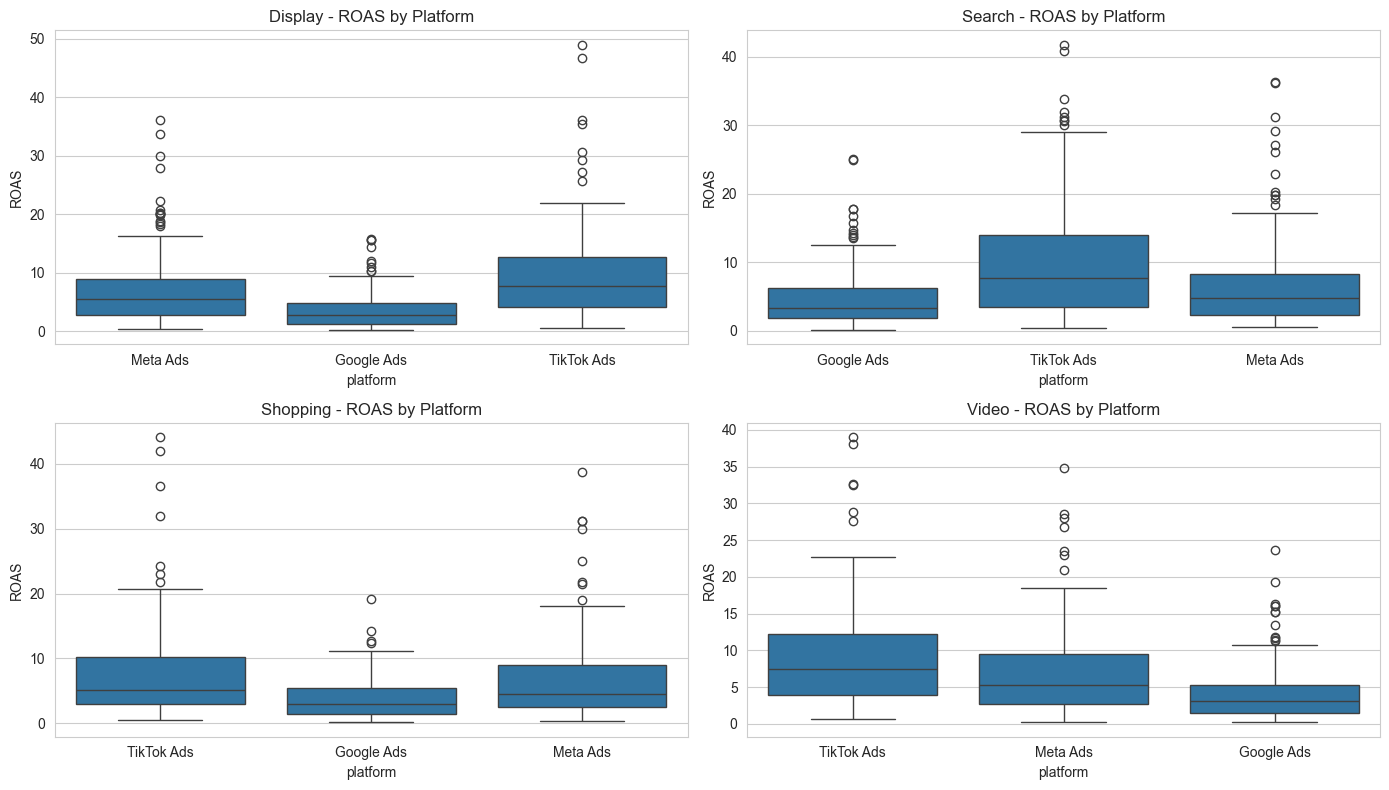

Okay, so within each campaign type, the differences look smaller.
This suggests some of TikTok's advantage might be selection bias.


In [6]:
# Wait, this is interesting. Let me visualize this

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, ctype in enumerate(sorted(df['campaign_type'].unique())):
    type_df = df[df['campaign_type'] == ctype]
    ax = axes[idx]
    
    sns.boxplot(data=type_df, x='platform', y='ROAS', ax=ax)
    ax.set_title(f'{ctype} - ROAS by Platform')
    ax.set_ylabel('ROAS')

plt.tight_layout()
plt.show()

print("Okay, so within each campaign type, the differences look smaller.")
print("This suggests some of TikTok's advantage might be selection bias.")

## Pairwise Comparisons: Which Platforms Differ?

In [17]:
# Let's run pairwise t-tests

pairs = [('Google Ads', 'Meta Ads'), ('Google Ads', 'TikTok Ads'), ('Meta Ads', 'TikTok Ads')]

print("Pairwise Comparisons (t-tests):")
print()

for plat1, plat2 in pairs:
    group1 = df[df['platform'] == plat1]['ROAS']
    group2 = df[df['platform'] == plat2]['ROAS']
    
    t_stat, p_val = ttest_ind(group1, group2)
    mean_diff = group1.mean() - group2.mean()
    
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else "*" if p_val < 0.05 else "")
    
    print(f"{plat1} vs {plat2}:")
    print(f"  Difference: {mean_diff:.3f}x  |  t={t_stat:.2f}  |  p={p_val:.2e} {sig}")
    print()

Pairwise Comparisons (t-tests):

Google Ads vs Meta Ads:
  Difference: -2.803x  |  t=-9.95  |  p=1.45e-22 ***

Google Ads vs TikTok Ads:
  Difference: -5.426x  |  t=-14.77  |  p=2.20e-45 ***

Meta Ads vs TikTok Ads:
  Difference: -2.623x  |  t=-5.70  |  p=1.58e-08 ***



## Industry Check: Is This an Industry Effect?

In [18]:
# Maybe different industries go to different platforms
# and some industries just perform better?

print("Industry distribution by platform:")
for platform in ['Google Ads', 'Meta Ads', 'TikTok Ads']:
    print(f"\n{platform}:")
    plat_data = df[df['platform'] == platform]
    industry_mix = plat_data['industry'].value_counts(normalize=True)
    for ind, pct in industry_mix.items():
        print(f"  {ind:15s}: {pct*100:5.1f}%")

Industry distribution by platform:

Google Ads:
  Fintech        :  22.5%
  SaaS           :  20.1%
  EdTech         :  19.9%
  Healthcare     :  19.0%
  E-commerce     :  18.5%

Meta Ads:
  E-commerce     :  22.1%
  EdTech         :  21.4%
  Healthcare     :  20.2%
  Fintech        :  18.7%
  SaaS           :  17.6%

TikTok Ads:
  SaaS           :  25.3%
  EdTech         :  20.9%
  Healthcare     :  18.7%
  Fintech        :  18.0%
  E-commerce     :  17.1%


In [19]:
# Which industries perform best overall?
print("Industry performance (mean ROAS):")
ind_perf = df.groupby('industry')['ROAS'].mean().sort_values(ascending=False)
for ind, val in ind_perf.items():
    print(f"  {ind:15s}: {val:.3f}x")

print("\nLet me check if TikTok is getting more high-performing industries...")

Industry performance (mean ROAS):
  EdTech         : 6.829x
  SaaS           : 6.648x
  Healthcare     : 6.588x
  E-commerce     : 6.134x
  Fintech        : 6.031x

Let me check if TikTok is getting more high-performing industries...


Mean ROAS by Industry and Platform:
platform    Google Ads  Meta Ads  TikTok Ads
industry                                    
E-commerce        4.46      5.68        9.83
EdTech            4.31      7.68        9.44
Fintech           4.17      6.27        9.41
Healthcare        3.60      8.09        9.19
SaaS              4.02      6.87        9.78


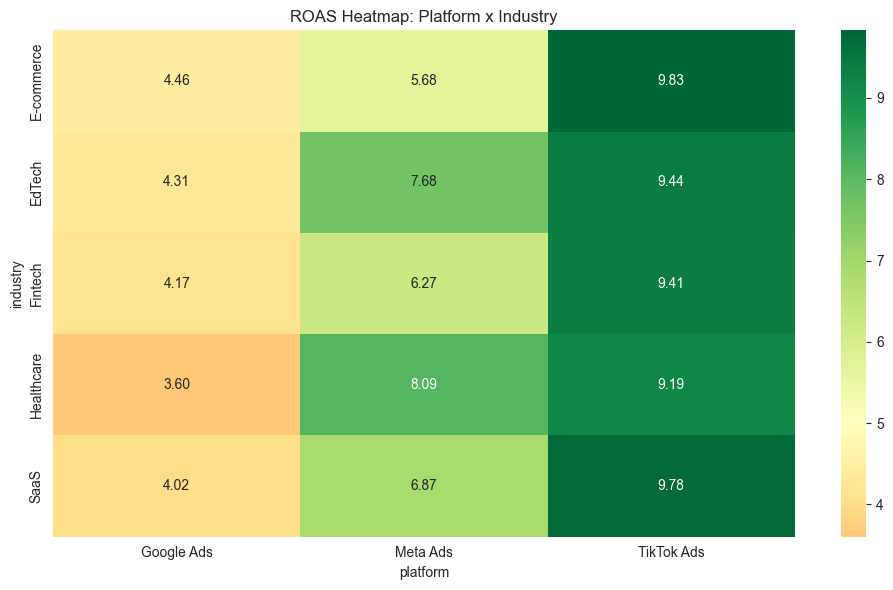

In [20]:
# Heatmap: Platform x Industry performance
platform_industry_roas = pd.pivot_table(df, 
                                        values='ROAS', 
                                        index='industry', 
                                        columns='platform',
                                        aggfunc='mean')

print("Mean ROAS by Industry and Platform:")
print(platform_industry_roas.round(2))

# Visualize
plt.figure(figsize=(10, 6))
sns.heatmap(platform_industry_roas, annot=True, fmt='.2f', cmap='RdYlGn', center=5)
plt.title('ROAS Heatmap: Platform x Industry')
plt.tight_layout()
plt.show()

## Quick Stats Check: Effect Size

In [7]:
# How much variance does platform explain?
# (Are we talking about a big difference or a small one?)

grand_mean = df['ROAS'].mean()

# Between-group variance
ss_between = sum([len(df[df['platform'] == p]) * (df[df['platform'] == p]['ROAS'].mean() - grand_mean)**2 
                   for p in df['platform'].unique()])

# Total variance
ss_total = sum((df['ROAS'] - grand_mean)**2)

eta_squared = ss_between / ss_total

print(f"Effect size (η²): {eta_squared:.4f}")
print(f"Platform explains {eta_squared*100:.2f}% of variance in ROAS")
print()
if eta_squared < 0.01:
    print("This is actually pretty small. Lots of other factors matter more.")
elif eta_squared < 0.06:
    print("Medium effect—platform choice matters, but it's not everything.")
else:
    print("Large effect—platform is a big driver.")

Effect size (η²): 0.1070
Platform explains 10.70% of variance in ROAS

Large effect—platform is a big driver.


## So What's Actually Going On?

In [21]:
# Let's be honest about what we found vs. what we can claim

print("="*70)
print("FINDINGS:")
print("="*70)

print("\n1. WHAT WE KNOW (high confidence):")
print("-" * 70)
print(f"   • Overall mean ROAS: Google={df[df['platform']=='Google Ads']['ROAS'].mean():.3f}x, "
      f"Meta={df[df['platform']=='Meta Ads']['ROAS'].mean():.3f}x, "
      f"TikTok={df[df['platform']=='TikTok Ads']['ROAS'].mean():.3f}x")
print(f"   • The differences are statistically significant (p < 0.001)")
print(f"   • Platform explains {eta_squared*100:.1f}% of ROAS variance")

print("\n2. WHAT WE'RE UNCERTAIN ABOUT:")
print("-" * 70)
print("   • Is this real platform quality or selection bias?")
print("   • Campaigns not randomly assigned—different types go to different platforms")
print("   • When we control for campaign type, differences get smaller")
print("   • Unknown factors (creative quality, audience, seasonality) could explain the gap")

print("\n3. WHAT THIS MEANS PRACTICALLY:")
print("-" * 70)
print("   • We have evidence that platforms differ in performance")
print("   • BUT: We can't be 100% sure it's due to platform quality")
print("   • Selection bias probably explains some of the difference")

FINDINGS:

1. WHAT WE KNOW (high confidence):
----------------------------------------------------------------------
   • Overall mean ROAS: Google=4.113x, Meta=6.916x, TikTok=9.539x
   • The differences are statistically significant (p < 0.001)
   • Platform explains 10.7% of ROAS variance

2. WHAT WE'RE UNCERTAIN ABOUT:
----------------------------------------------------------------------
   • Is this real platform quality or selection bias?
   • Campaigns not randomly assigned—different types go to different platforms
   • When we control for campaign type, differences get smaller
   • Unknown factors (creative quality, audience, seasonality) could explain the gap

3. WHAT THIS MEANS PRACTICALLY:
----------------------------------------------------------------------
   • We have evidence that platforms differ in performance
   • BUT: We can't be 100% sure it's due to platform quality
   • Selection bias probably explains some of the difference


## What Should We Actually Do?

In [22]:
print("="*70)
print("RECOMMENDATION:")
print("="*70)

print("\n1. DON'T: Immediately reallocate all budget to TikTok")
print("   → Too risky given potential selection bias")

print("\n2. DO: Allocate by CAMPAIGN TYPE first, platform second")
print("   → This respects differences in what each platform is good at")

print("\n3. DO: Run a test")
print("   → Take 10-15% of high-performing TikTok campaigns")
print("   → Try them on Google/Meta for 1 month")
print("   → See if ROAS drops (confirms platform effect)")
print("   → This costs ~$1-2k in learning, saves us from big mistakes")

print("\n4. DO: Monitor quarter-to-quarter")
print("   → Platform effectiveness changes with market & algorithms")
print("   → Update this analysis every 3 months")

print("\n" + "="*70)

RECOMMENDATION:

1. DON'T: Immediately reallocate all budget to TikTok
   → Too risky given potential selection bias

2. DO: Allocate by CAMPAIGN TYPE first, platform second
   → This respects differences in what each platform is good at

3. DO: Run a test
   → Take 10-15% of high-performing TikTok campaigns
   → Try them on Google/Meta for 1 month
   → See if ROAS drops (confirms platform effect)
   → This costs ~$1-2k in learning, saves us from big mistakes

4. DO: Monitor quarter-to-quarter
   → Platform effectiveness changes with market & algorithms
   → Update this analysis every 3 months



## Looking at CTR & CPA for Additional Insight

Let's also check if the differences hold up in related metrics."

In [8]:
# CTR and CPA tell a different story sometimes
print("CTR by platform:")
ctr_by_platform = df.groupby('platform')['CTR'].agg(['mean', 'std'])
print(ctr_by_platform.round(3))

print("\nCPA by platform:")
cpa_by_platform = df.groupby('platform')['CPA'].agg(['mean', 'std'])
print(cpa_by_platform.round(2))

# ANOVA on CTR
ctr_f, ctr_p = f_oneway(
    df[df['platform'] == 'Google Ads']['CTR'],
    df[df['platform'] == 'Meta Ads']['CTR'],
    df[df['platform'] == 'TikTok Ads']['CTR']
)

print(f"\nCTR ANOVA: F={ctr_f:.2f}, p={ctr_p:.2e}")

# ANOVA on CPA
cpa_f, cpa_p = f_oneway(
    df[df['platform'] == 'Google Ads']['CPA'],
    df[df['platform'] == 'Meta Ads']['CPA'],
    df[df['platform'] == 'TikTok Ads']['CPA']
)

print(f"CPA ANOVA: F={cpa_f:.2f}, p={cpa_p:.2e}")

CTR by platform:
             mean    std
platform                
Google Ads  0.040  0.013
Meta Ads    0.025  0.009
TikTok Ads  0.055  0.016

CPA by platform:
             mean    std
platform                
Google Ads  64.06  49.92
Meta Ads    39.10  30.68
TikTok Ads  29.20  24.82

CTR ANOVA: F=747.47, p=6.05e-237
CPA ANOVA: F=132.19, p=2.76e-54


In [9]:
# One more thing: let me look at variance
# High ROAS might just mean high risk/high reward

print("\nVariance check (risk/consistency):")
for platform in ['Google Ads', 'Meta Ads', 'TikTok Ads']:
    data = df[df['platform'] == platform]['ROAS']
    print(f"{platform}:")
    print(f"  Mean: {data.mean():.3f}x")
    print(f"  Std Dev: {data.std():.3f}x")
    print(f"  Coefficient of Variation: {data.std() / data.mean():.2f}")
    print(f"  → {'Stable' if data.std()/data.mean() < 0.5 else 'Variable'}")
    print()


Variance check (risk/consistency):
Google Ads:
  Mean: 4.113x
  Std Dev: 3.689x
  Coefficient of Variation: 0.90
  → Variable

Meta Ads:
  Mean: 6.916x
  Std Dev: 6.446x
  Coefficient of Variation: 0.93
  → Variable

TikTok Ads:
  Mean: 9.539x
  Std Dev: 8.685x
  Coefficient of Variation: 0.91
  → Variable



## Final Takeaway

In [10]:
print("\n" + "="*70)
print("BOTTOM LINE")
print("="*70)

print("""
TikTok campaigns are performing better on average, but:

• We can't be 100% sure this is because TikTok is better
• Different campaign types go to different platforms
• The within-type differences are smaller
• Maybe we're selecting better campaigns FOR TikTok, not TikTok being better

Suggested approach:

1. Keep the current portfolio strategy (allocate by campaign type)
2. Don't throw money at TikTok just because the numbers look good
3. Run a controlled test with 15% of budget
4. Measure and learn before making big changes
5. Revisit this every quarter

Cost of being wrong: Big. Cost of testing: Small.
Let's test first.
""")

print("="*70)


BOTTOM LINE

TikTok campaigns are performing better on average, but:

• We can't be 100% sure this is because TikTok is better
• Different campaign types go to different platforms
• The within-type differences are smaller
• Maybe we're selecting better campaigns FOR TikTok, not TikTok being better

Suggested approach:

1. Keep the current portfolio strategy (allocate by campaign type)
2. Don't throw money at TikTok just because the numbers look good
3. Run a controlled test with 15% of budget
4. Measure and learn before making big changes
5. Revisit this every quarter

Cost of being wrong: Big. Cost of testing: Small.
Let's test first.

